<a href="https://colab.research.google.com/github/victoriairungu99-creator/CDAV-course/blob/main/A_B_Testing_Case_Study_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Understand the Dataset

In [12]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset and inspect the first few rows
df = pd.read_csv("/content/abtest.csv")
df.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [13]:
# 2. Number of observations and variables
print("Shape of dataset:", df.shape)


Shape of dataset: (100, 6)


In [14]:
# 3 & 4. Data types and missing values check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [15]:
df.isnull().sum()#check whether any column has null values

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


#Answers & Interpretations:
1. First Few Observations: The dataset displays user interactions, tracking user ID, test group (control/treatment), landing page version (old/new), session duration (time_spent_on_the_page), conversion status (yes/no), and preferred language.

2. Dimensions: The dataset contains 100 observations (rows) and 6 variables (columns)

3. Data Types: user_id(int64) -group: Categorical text (object) -landing_page: Categorical text (object) -time_spent_on_the_page: Continuous numeric (float64)  -converted: Categorical text (object)  -language_preferred: Categorical text (object)

4. Missing Values: There are 0 missing values across all 100 rows (each column has 100 non-null entries).

5. Variable Classification: Numerical: time_spent_on_the_page (continuous ratio scale).  Categorical: group (nominal), landing_page (nominal), converted (nominal/binary), and language_preferred (nominal).  

6. Identifier Variable Treatment: user_id is stored numerically as an integer, but it should not be treated as a numerical measurement.  Reason: It is an arbitrary unique identifier assigned to distinguish individuals. Performing arithmetic operations (such as calculating the mean or standard deviation of user IDs) holds no mathematical or business meaning.

#2. Descriptive Statistics

In [16]:
# Calculate descriptive statistics
time_spent = df['time_spent_on_the_page']

mean = time_spent.mean()
median = time_spent.median()
std_dev = time_spent.std()
min_val = time_spent.min()
max_val = time_spent.max()
q1 = time_spent.quantile(0.25)
q3 = time_spent.quantile(0.75)
iqr = q3 - q1

print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Minimum: {min_val:.2f}")
print(f"Maximum: {max_val:.2f}")
print(f"Q1 (25th Percentile): {q1:.2f}")
print(f"Q3 (75th Percentile): {q3:.2f}")
print(f"IQR: {iqr:.2f}")

Mean: 5.38
Median: 5.42
Standard Deviation: 2.38
Minimum: 0.19
Maximum: 10.71
Q1 (25th Percentile): 3.88
Q3 (75th Percentile): 7.02
IQR: 3.14


#Interpretation & Answers (Questions 7 & 8):
7. What do these statistics tell you about how long users spend on the landing page?:  
Central Tendency: On average, visitors spend approximately 5.38 minutes on the landing page, with a typical median engagement time of 5.42 minutes.

 Variability & Spread: The standard deviation is 2.38 minutes, showing moderate dispersion around the average.

 Range & Middle 50%: User session durations range widely from as short as 0.19 minutes to as long as 10.71 minutes. The middle 50% of all visitors ($IQR$) spend between 3.88 and 7.02 minutes on the page.

 8. Compare the mean and median. What does this suggest about the distribution?:

 The sample mean (5.38) and the median (5.42) are virtually identical ($\approx 5.4$).This close alignment suggests that the overall distribution of time_spent_on_the_page is approximately symmetric (bell-shaped) and not heavily skewed by extreme outliers in either direction.

#Data Visualization

#1. Distribution of Time Spent on the Page

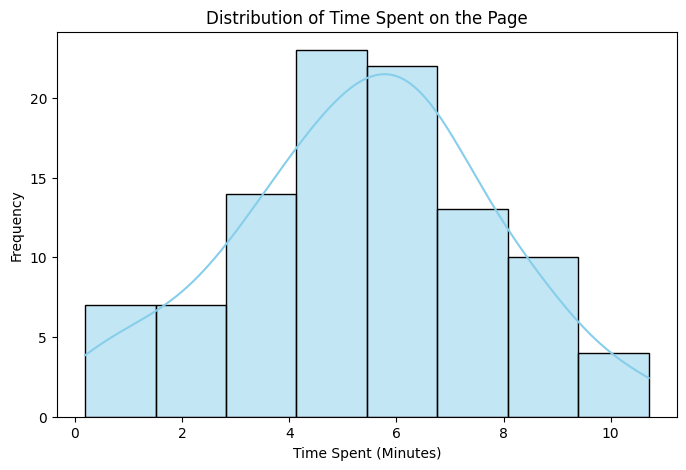

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['time_spent_on_the_page'], kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Time Spent on the Page')
plt.xlabel('Time Spent (Minutes)')
plt.ylabel('Frequency')
plt.show()

Main Pattern: The histogram shows an approximately normal, bell-shaped distribution centered around 5 to 6 minutes, with values ranging continuously from under 1 minute to around 10.7 minutes.

#2. Time Spent on Page by Group (Control vs. Treatment)

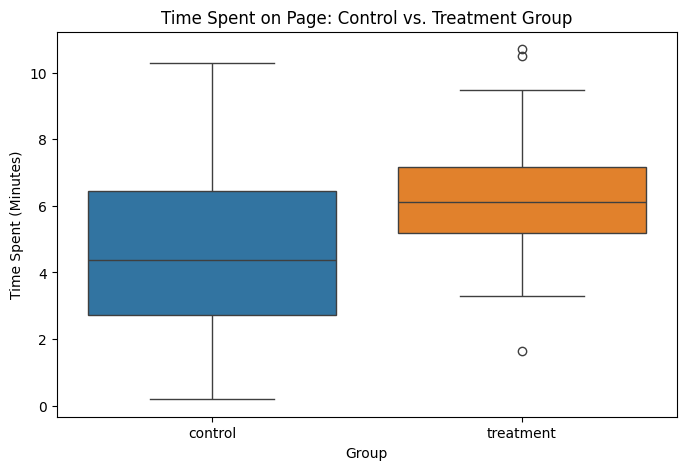

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='time_spent_on_the_page', data=df, hue='group', legend=False)
plt.title('Time Spent on Page: Control vs. Treatment Group')
plt.xlabel('Group')
plt.ylabel('Time Spent (Minutes)')
plt.show()

Main Pattern: The median and interquartile range for the treatment group (new landing page) are visibly higher than those of the control group (old landing page). Treatment group times cluster higher (median $\approx 6.1$ min) with lower overall dispersion compared to control (median $\approx 4.4$ min).

#3. Conversion Count (Yes / No)

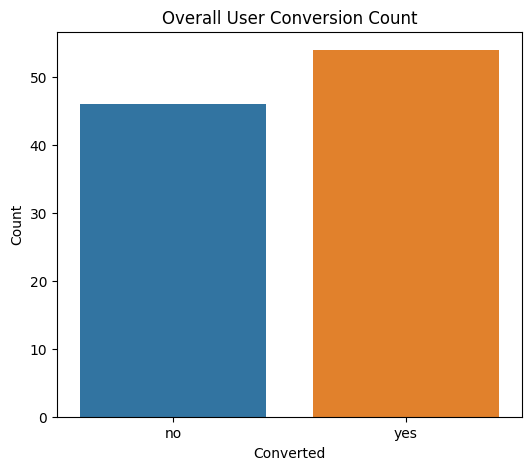

In [19]:
plt.figure(figsize=(6, 5))
sns.countplot(x='converted', hue='converted', data=df, legend=False)
plt.title('Overall User Conversion Count')
plt.xlabel('Converted')
plt.ylabel('Count')
plt.show()

Main Pattern: Conversions are relatively balanced, with 54 users converting (yes) and 46 users not converting (no) across the sample of 100 individuals.

#4. Preferred Language Distribution

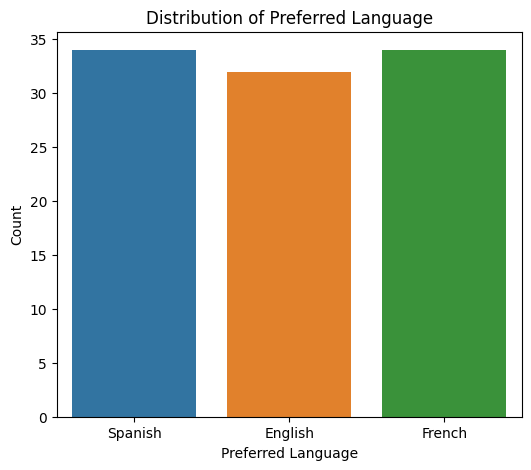

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(x='language_preferred', data=df, hue='language_preferred')
plt.title('Distribution of Preferred Language')
plt.xlabel('Preferred Language')
plt.ylabel('Count')
plt.show()

Main Pattern: The sample is evenly split across all three language options: Spanish (34), French (34), and English (32).

#Average time spent on the page for the control group and the treatment group

In [21]:
# 9. Calculate average time spent for control and treatment groups
mean_time = df.groupby('group')['time_spent_on_the_page'].mean()

print(f"Mean time spent (Control): {mean_time['control']:.2f}")
print(f"Mean time spent (Treatment): {mean_time['treatment']:.2f}")

Mean time spent (Control): 4.53
Mean time spent (Treatment): 6.22


9. Average Time SpentControl Group (Old Landing Page): 4.53 minutes  Treatment Group (New Landing Page): 6.22 minutes  

10. Based only on descriptive statistics, does the new landing page appear to perform better?:

-Yes. Descriptive statistics show that users in the treatment group spent an average of 6.22 minutes on the page compared to 4.53 minutes for the control group—an increase of approximately 1.69 minutes (or about 37.3% more time). Based purely on sample averages, the new page appears to engage users for longer.  

11. Can descriptive statistics alone establish that the new landing page causes users to spend more time on the page?:

-No. Descriptive statistics summarize only the observed sample data and cannot rule out the possibility that the difference is due to random sampling variation (chance).  To establish statistical significance and make causal inferences about the wider population of users, formal inferential statistical tests (such as hypothesis testing) are required.  